In [1]:
import pandas as pd
import pandahouse as ph

#параметры соединения - нужны, чтобы подключиться к нужной схеме данных
connection = {'host': 'http://clickhouse.lab.karpov.courses:8123',
'database':'simulator_20260620',
'user':'student',
'password':'dpo_python_2020'
}

In [2]:
q = """
SELECT exp_group, 
    user_id,
    sum(action = 'like') as likes,
    sum(action = 'view') as views,
    likes/views as ctr
FROM simulator_20260620.feed_actions 
WHERE toDate(time) between '2026-05-22' and '2026-05-28'
    and exp_group in (2,3)
GROUP BY exp_group, user_id
"""

df = ph.read_clickhouse(q, connection=connection)

df.groupby('exp_group').count() 

,user_id,likes,views,ctr
exp_group,,,,
2,8362,8362,8362,8362
3,8425,8425,8425,8425


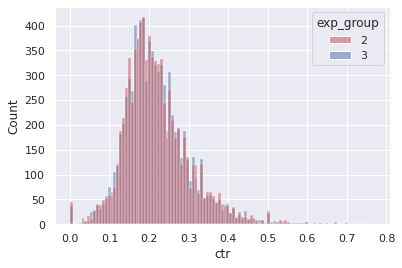

In [3]:
import seaborn as sns

# Сделаем графики в seaborn покрупнее
sns.set(rc={'figure.figsize':(11.7,8.27)})

groups = sns.histplot(data = df, 
              x='ctr', 
              hue='exp_group', 
              palette = ['r', 'b'],
              alpha=0.5,
              kde=False)

## Задание 1. A/A тест

Проверка работы системы сплитования. В случае верного разделения статистически значимые различия между двумя группами встречаются только в результате случайного ложного срабатывания (в 5% случаев). Таким образом, случаев отклонения нулевой гипотезы должно быть приблизительно 5%.

In [ ]:
from scipy import stats

H0: между группами отсутствуют статистически значимые различия в средних значениях CTR

H1: между группами есть статистически значимые различия в средних значениях CTR

In [30]:
p_values = []

for _ in range(10000):
    sample2 = df[df.exp_group == 2].ctr.sample(n=500, replace=False)
    sample3 = df[df.exp_group == 3].ctr.sample(n=500, replace=False)
    t_stat, p_val = stats.ttest_ind(sample2, sample3, equal_var=False)
    p_values.append(p_val)

In [24]:
import numpy as np

p_values = np.array(p_values)
false_positives = np.mean(p_values < 0.05)
p_val = np.array(p_values < 0.05)

print(f"Доля ошибок первого рода (p-value < 0.05): {false_positives:.4f}")

Доля ошибок первого рода (p-value < 0.05): 0.0480


**Гистограмма распределения p-value**

<Axes: ylabel='Count'>

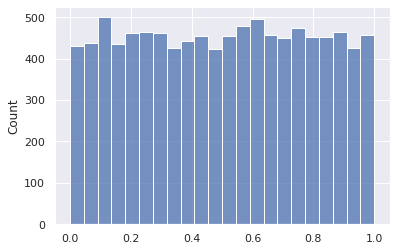

In [32]:
sns.histplot(data = p_values)

In [29]:
A_gt_B = 0
for _ in range(10000):
    A_gt_B+= df[df.exp_group == 2].ctr.sample(n=500, replace=False).values[0] > df[df.exp_group == 3].ctr.sample(n=500, replace=False).values[0]
    
print('В', A_gt_B/100, '% случаев A > B. Должно получиться около 50%')

В 50.05 % случаев A > B. Должно получиться около 50%


Распределение получившихся p-value является примерно равномерным. Доля p-value ниже порога значимости составляет около 0.048. Это примерно столько, сколько ожидалось в теории. Значит, система сплитования работает корректно.

## Задание 2. A/B тест

Пришло время проанализировать результаты эксперимента, который мы провели вместе с командой дата сайентистов. Эксперимент проходил с 2026-05-29 по 2026-06-04 включительно. Для эксперимента были задействованы 2 и 1 группы. 

В группе 2 был использован один из новых алгоритмов рекомендации постов, группа 1 использовалась в качестве контроля. 

Основная гипотеза заключается в том, что новый алгоритм во 2-й группе приведет к увеличению CTR. 

Задача — проанализировать данные А/B-теста. 

In [33]:
q = """
SELECT exp_group, 
    user_id,
    sum(action = 'like') as likes,
    sum(action = 'view') as views,
    likes/views as ctr
FROM simulator_20260620.feed_actions 
WHERE toDate(time) between '2026-05-29' and '2026-06-04'
    and exp_group in (1,2)
GROUP BY exp_group, user_id
"""

In [35]:
dff = ph.read_clickhouse(q, connection=connection)

In [40]:
dff.head()

,exp_group,user_id,likes,views,ctr
0,1,109963,3,15,0.200000
1,1,26117,32,141,0.226950
2,1,138232,18,73,0.246575
3,1,26295,39,141,0.276596
4,1,18392,7,32,0.218750


группа 1 - контрольная, группа 2 - экспериментальная, предложен новый алгоритм рекомендации постов

In [37]:
# проведение t-теста

stats.ttest_ind(dff[dff.exp_group == 1].ctr,
                dff[dff.exp_group == 2].ctr,
                equal_var=False)

Ttest_indResult(statistic=0.4051491913112757, pvalue=0.685373331140751)

In [63]:
dff[dff.exp_group == 1].ctr.mean()

0.216773994120072

In [64]:
dff[dff.exp_group == 2].ctr.mean()

0.2161016893237817

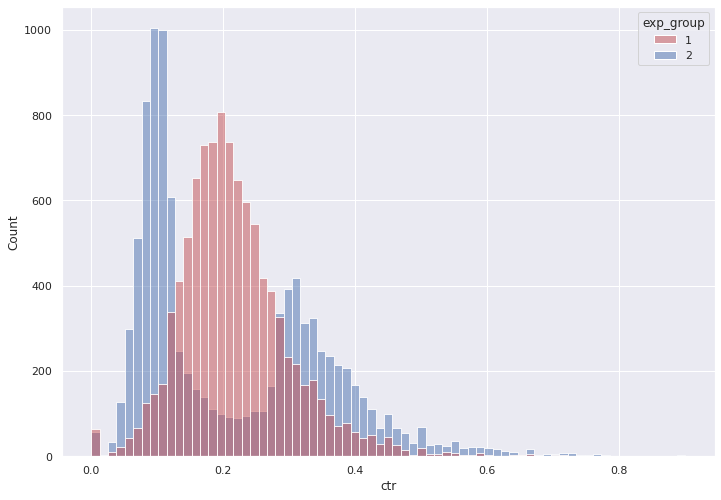

In [39]:
sns.set(rc={'figure.figsize':(11.7,8.27)})

groups = sns.histplot(data = dff, 
              x='ctr', 
              hue='exp_group', 
              palette = ['r', 'b'],
              alpha=0.5,
              kde=False)

Вывод: при проведении t-теста получившийся p-value оказался выше уровня значимости 0,05, что означает, что статистически значимых различий между группами выявлено не было. График распределений двух групп позволяет выдвинуть предположение, что такой результат был получен, так как средние значения распределений совпадают, при этом визуально есть значительные участки несовпадения распределений. То есть результат t-теста может обосновываться равенством средних значений. Кроме того, распределение экспериментальной группы отличается от нормального. Оно бимодальное, не является симметричным, что отрицательно влияет на точность результатов t-теста. Большая часть значений собрана в областях наиболее высоких и низкий значений. 

In [41]:
# проведение теста Манна-Уитни

stats.mannwhitneyu(dff[dff.exp_group == 1].ctr, 
                   dff[dff.exp_group == 2].ctr,
                   alternative = 'two-sided')

MannwhitneyuResult(statistic=55189913.0, pvalue=4.632205841806026e-45)

Тест Манна-Уитни указывает на наличие статистически значимых различий между группами. В этом случае при равенстве средних двух распределений тест отличие прокрашивается.

In [42]:
# функция расчета сглаженного ctr

def get_smothed_ctr(user_likes, user_views, global_ctr, alpha):
    smothed_ctr = (user_likes + alpha * global_ctr) / (user_views + alpha)
    return smothed_ctr

In [44]:
global_ctr_1 = dff[dff.exp_group == 1].likes.sum()/dff[dff.exp_group == 1].views.sum()
global_ctr_2 = dff[dff.exp_group == 2].likes.sum()/dff[dff.exp_group == 2].views.sum()

/tmp/ipykernel_49/2207210429.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(group_control.ctr,


<Axes: xlabel='ctr'>

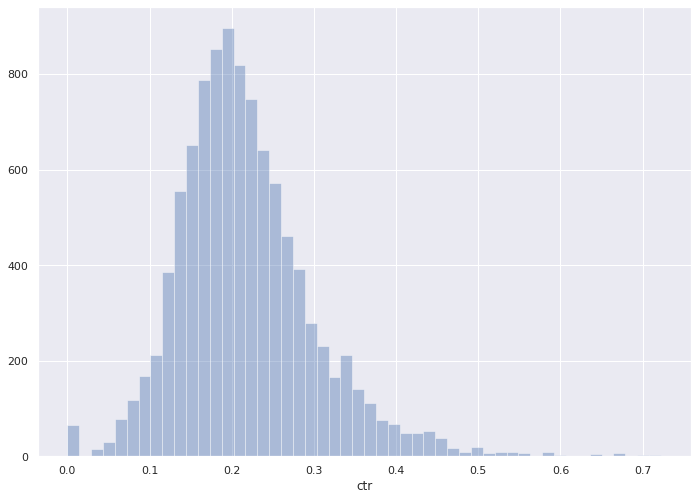

In [48]:
group_control = dff[dff.exp_group == 1].copy()
sns.distplot(group_control.ctr, 
             kde = False)

In [49]:
group_control['smothed_ctr'] = dff.apply(
    lambda x: get_smothed_ctr(x['likes'], x['views'], global_ctr_1, 5), axis=1
)

In [50]:
group_control.head()

,exp_group,user_id,likes,views,ctr,smothed_ctr
0,1,109963,3,15,0.200000,0.202401
1,1,26117,32,141,0.226950,0.226356
2,1,138232,18,73,0.246575,0.244205
3,1,26295,39,141,0.276596,0.274302
4,1,18392,7,32,0.218750,0.217514


/tmp/ipykernel_49/2755405638.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(group_control.smothed_ctr,


<Axes: xlabel='smothed_ctr'>

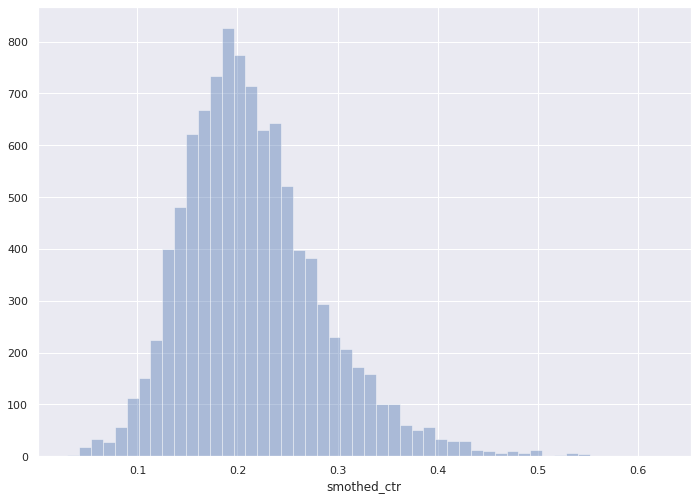

In [51]:
sns.distplot(group_control.smothed_ctr, 
             kde = False)

/tmp/ipykernel_49/765170353.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(group_test.ctr,


<Axes: xlabel='ctr'>

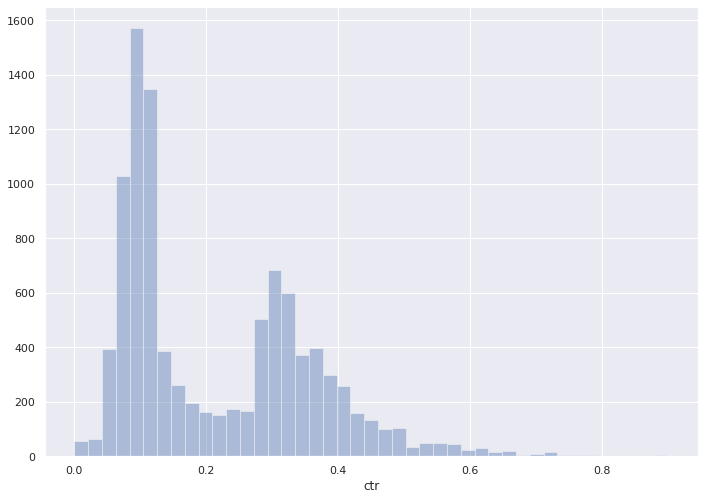

In [52]:
# расчет сглаженного ctr для экспериментальной группы (2)

group_test = dff[dff.exp_group == 2].copy()
sns.distplot(group_test.ctr, 
             kde = False)

In [53]:
group_test['smothed_ctr'] = dff.apply(
    lambda x: get_smothed_ctr(x['likes'], x['views'], global_ctr_2, 5), axis=1
)

/tmp/ipykernel_49/4157042403.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(group_test.smothed_ctr,


<Axes: xlabel='smothed_ctr'>

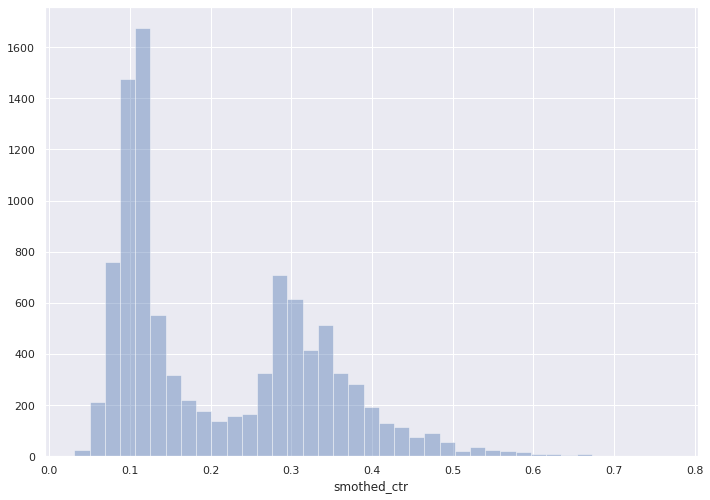

In [54]:
sns.distplot(group_test.smothed_ctr, 
             kde = False)

In [55]:
group_test.head()

,exp_group,user_id,likes,views,ctr,smothed_ctr
5,2,131473,9,108,0.083333,0.088507
6,2,23985,7,87,0.080460,0.086970
7,2,24523,11,101,0.108911,0.113219
8,2,32420,13,44,0.295455,0.285740
9,2,24239,40,90,0.444444,0.431592


In [57]:
# t-тест для сглаженного ctr

stats.ttest_ind(group_control.smothed_ctr,
                group_test.smothed_ctr,
                equal_var=False)

Ttest_indResult(statistic=1.9460491517027683, pvalue=0.05166679015318526)

In [60]:
all_groups = pd.concat([group_control, group_test])

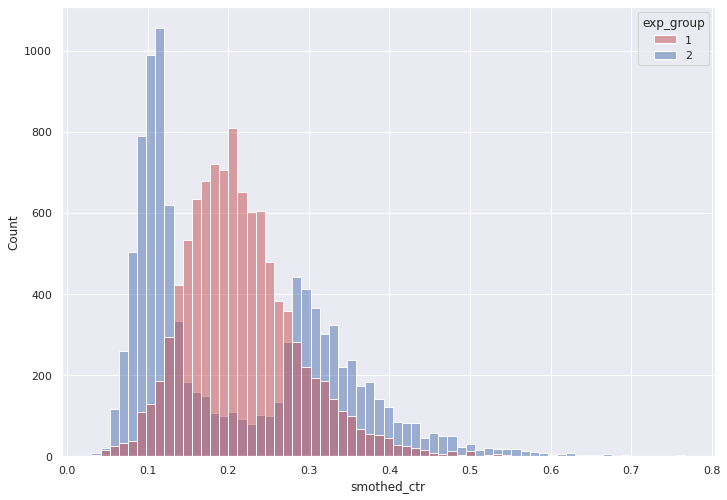

In [62]:
sns.set(rc={'figure.figsize':(11.7,8.27)})

groups = sns.histplot(data = all_groups, 
              x='smothed_ctr', 
              hue='exp_group', 
              palette = ['r', 'b'],
              alpha=0.5,
              kde=False)

In [65]:
group_control.smothed_ctr.mean()

0.21527988017565183

In [66]:
group_test.smothed_ctr.mean()

0.21250810594606076

In [67]:
# тест Манна-Уитни для сглаженного ctr

stats.mannwhitneyu(group_control.smothed_ctr,
                   group_test.smothed_ctr,
                   alternative = 'two-sided')

MannwhitneyuResult(statistic=55528353.0, pvalue=2.396534039374286e-50)

Вывод: при сравнении групп на основе сглаженного ctr результаты тестов такие же, как и в случае с обычным ctr. Распределение экспериментальной группы по сглаженному ctr так и сохранило ассиметричный вид с двумя пиками. По t-тесту значимых различий не было найдено, а по Манну-Уитни они были зафиксированы.

### Проверка пуассоновским бутстрапом

In [70]:
def bootstrap(likes1, views1, likes2, views2, n_bootstrap=2000):

    poisson_bootstraps1 = stats.poisson(1).rvs(
        (n_bootstrap, len(likes1))).astype(np.int64)

    poisson_bootstraps2 = stats.poisson(1).rvs(
            (n_bootstrap, len(likes2))).astype(np.int64)
    
    globalCTR1 = (poisson_bootstraps1*likes1).sum(axis=1)/(poisson_bootstraps1*views1).sum(axis=1)
    
    globalCTR2 = (poisson_bootstraps2*likes2).sum(axis=1)/(poisson_bootstraps2*views2).sum(axis=1)

    return globalCTR1, globalCTR2

In [73]:
df = ph.read_clickhouse(q, connection=connection)

In [74]:
likes1 = df[df.exp_group == 1].likes.to_numpy()
views1 = df[df.exp_group == 1].views.to_numpy()
likes2 = df[df.exp_group == 2].likes.to_numpy()
views2 = df[df.exp_group == 2].views.to_numpy()

In [75]:
ctr1, ctr2 = bootstrap(likes1, views1, likes2, views2)

<Axes: ylabel='Count'>

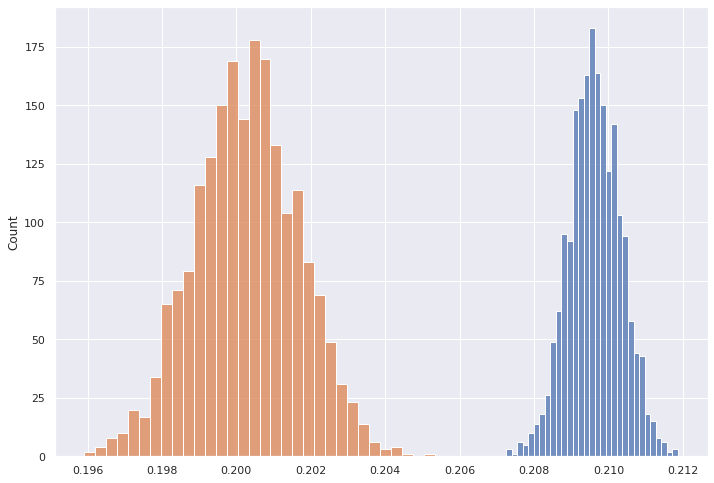

In [76]:
sns.histplot(ctr1)
sns.histplot(ctr2)

<Axes: ylabel='Count'>

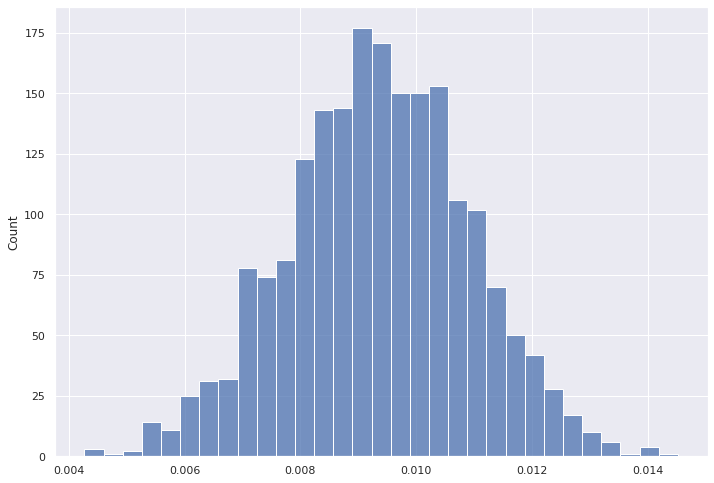

In [91]:
sns.histplot(ctr1 - ctr2)

При сравнении распределений общегрупповых ctr этим методом было выявлено, что они не пересекаются. Общегрупповые значения контрольной группы больше, чем у экспериментальной группы. Но это говорит о том, что с применением нового алгоритма рекомендации постов ctr, напротив, снижается. Этот метод позволяет посмотреть на разницу распределений даже при равенстве средних (по причине наличия во втором распределении ассиметрии в сторону совсем низких и совсем высоких значений).

### Бакетное преобразование

In [79]:
q = """

SELECT exp_group, bucket,
    sum(likes)/sum(views) as bucket_ctr,
    quantileExact(0.9)(ctr) as ctr9
FROM (SELECT exp_group, 
        xxHash64(user_id)%50 as bucket,
        user_id,
        sum(action = 'like') as likes,
        sum(action = 'view') as views,
        likes/views as ctr
    FROM {db}.feed_actions 
    WHERE toDate(time) between '2026-05-29' and '2026-06-04'
        and exp_group in (1,2)
    GROUP BY exp_group, bucket, user_id)
GROUP BY exp_group, bucket
"""

df = ph.read_clickhouse(q, connection=connection)

In [90]:
df.groupby('exp_group', as_index=False).bucket.count()

# получилось равное количество по группам, все нормально

,exp_group,bucket
0,1,50
1,2,50


In [80]:
# t-тест

stats.ttest_ind(df[df.exp_group == 1].bucket_ctr, 
                   df[df.exp_group == 2].bucket_ctr, 
                   equal_var = False)

Ttest_indResult(statistic=5.614819358149381, pvalue=4.592644937473873e-07)

In [81]:
# тест Манна-Уитни
stats.mannwhitneyu(df[df.exp_group == 1].bucket_ctr, 
                   df[df.exp_group == 2].bucket_ctr, 
                   alternative = 'two-sided')

MannwhitneyuResult(statistic=1997.0, pvalue=2.6576427804010095e-07)

По итогам бакетного преобразования оба теста указывают на наличие статистически значимых различий между группами. 

**Общий вывод:**

Возможно, такие изменения по итогам введения нового алгоритма произошли, так как он сработал более эффективно для старых пользователей, о которых уже есть много данных в приложении, и хуже для новых пользователей ленты новостей.

Рекомендация: по итогам анализа можно сделать вывод, что раскатывать изменение на всех пользователей не стоит. Различия были зафиксированы в большистве тестов, но как показывают результаты пуассоновского бутстрапа, общегрупповой ctr в экспериментальной группе ниже, чем в контрольной (то есть стало хуже). Есть среди пользователей экспериментальной группы те, у кого ctr совсем низкий, а у кого он выше, чем в контрольной. Но общегрупповой результат стал ниже. 